# Лабораторная работа №8
## *Определение музыкальных трезвучий*
по курсу Цифровая обработка сигналов  
  
**направление:** Речевые технологии и машинное обучение  
**преподаватель:** Рыбин Сергей Витальевич  
**выполнили:** Иванова Мария Кирилловна  
**группа:** М4121

In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
from math import pi, cos, log2
from scipy.signal import find_peaks

### Загрузка и воспроизведение исходного сигнала*
*Вариант сигнала DTLab5

In [2]:
def draw_waveform(y, sr=44100, title="Waveform"):

    t = np.arange(len(y)) / sr

    plt.figure(figsize=(14, 4))
    plt.plot(t, y, color="#A1B7F4")
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.title(title)
    plt.grid(True)
    plt.show()

Len is 80000. Sample rate is 16000
Исходная частота дискретизации: 16000


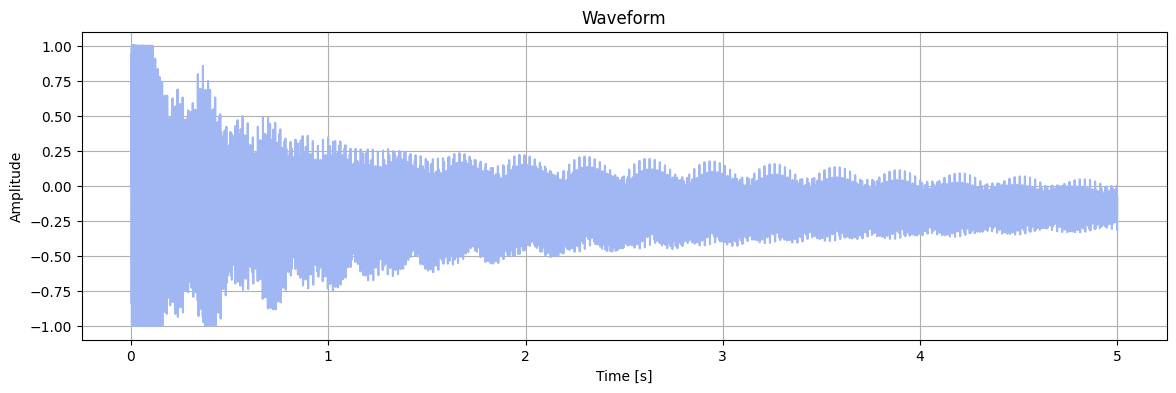

In [ ]:
signal, sr = librosa.core.load('./DTLab5.wav', sr=None)
print(f"Len is {len(signal)}. Sample rate is {sr}")
print("Исходная частота дискретизации:", sr)
player = ipd.Audio(signal, rate=sr)
ipd.display(player)
draw_waveform(signal, sr=sr)

### Вычисление спектра

In [8]:
n_fft = 8192 
hop_length = n_fft // 4

# STFT
D = librosa.stft(signal, n_fft=n_fft, hop_length=hop_length)
magnitude = np.abs(D)

# Средний спектр по времени
avg_spectrum = np.mean(magnitude, axis=1)

# Логарифмический спектр (в дБ)
log_spectrum = librosa.amplitude_to_db(avg_spectrum, ref=np.max)

# Частоты для спектра
frequencies = librosa.fft_frequencies(sr=sr, n_fft=n_fft)

### Отображение спектра

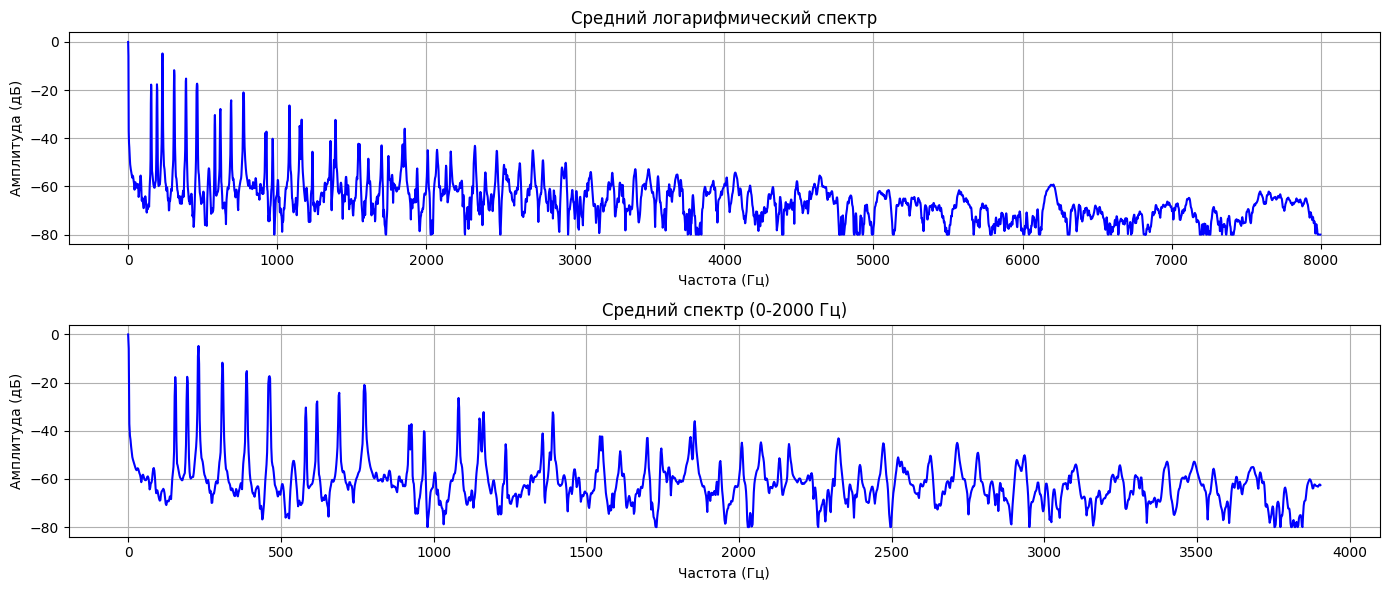

In [9]:
plt.figure(figsize=(14, 6))
plt.subplot(2, 1, 1)
plt.plot(frequencies[:n_fft//2], log_spectrum[:n_fft//2], color='b')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.title('Средний логарифмический спектр')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(frequencies[:2000], log_spectrum[:2000], color='b')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.title('Средний спектр (0-2000 Гц)')
plt.grid(True)
plt.tight_layout()
plt.show()

### Определение трезвучия

In [10]:
notes = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

In [11]:
# Функция для перевода частоты в номер полутона
def freq_to_midi(freq):
    return 12 * log2(freq / 440.0) + 69

In [12]:
# Функция для перевода номера полутона в ноту
def midi_to_note(midi_num):
    note_index = int(round(midi_num)) % 12
    octave = int(midi_num // 12) - 1
    return notes[note_index] + str(octave)

### Поиск пиков в спектре

In [14]:
mask = frequencies <= 2000
freq_subset = frequencies[mask]
spec_subset = log_spectrum[mask]

In [15]:
peaks, properties = find_peaks(spec_subset, height=-50, distance=5)
peak_freqs = freq_subset[peaks]
peak_amps = spec_subset[peaks]

In [16]:
# Функция для поиска гармоник и их обертонов
def find_harmonic_series(freqs, amps, max_harmonics=5, tolerance=0.01):

    series = []
    used_freqs = set()
    
    # Сортировка пиков по убыванию амплитуды
    sorted_indices = np.argsort(amps)[::-1]
    
    for idx in sorted_indices:
        f0 = freqs[idx]
        
        # Пропуск, если частота уже использована в другой серии
        if f0 in used_freqs:
            continue
        
        # Поиск гармоник для этой частоты
        harmonics = [(1, f0, amps[idx])] 
        
        for n in range(2, max_harmonics + 1):
            target_freq = f0 * n
            
            # Поиск ближайшей частоты к целевой гармонике
            distances = np.abs(freqs - target_freq)
            closest_idx = np.argmin(distances)

            if distances[closest_idx] / target_freq < tolerance:
                harmonic_freq = freqs[closest_idx]
                harmonic_amp = amps[closest_idx]
                harmonics.append((n, harmonic_freq, harmonic_amp))
                used_freqs.add(harmonic_freq)
        
        # Если найдена хотя бы одна пара (гармоника + обертон)
        if len(harmonics) >= 2:
            # Вычисление "силы" серии - суммы амплитуд гармоник
            total_strength = sum(amp for _, _, amp in harmonics)
            series.append({
                'f0': f0,
                'harmonics': harmonics,
                'strength': total_strength,
                'num_harmonics': len(harmonics)
            })
            used_freqs.add(f0)
    
    # Сортировка серий по суммарной амплитуде
    series.sort(key=lambda x: x['strength'], reverse=True)
    return series

In [17]:
# Находим гармонические серии
harmonic_series = find_harmonic_series(peak_freqs, peak_amps, max_harmonics=4)
print(f"Найдено {len(harmonic_series)} гармонических серий")


Найдено 5 гармонических серий


In [25]:
# 3 самые сильные серии (F1, F2, F3)
selected_series = harmonic_series[:3]

# Получаем основные частоты, отсортированные по возрастанию
main_freqs = [s['f0'] for s in selected_series]
main_freqs.sort()

print("\nОсновные частоты (фундаментальные):")
for i, (freq, series) in enumerate(zip(main_freqs, selected_series)):
    midi = freq_to_midi(freq)
    note = midi_to_note(midi)
    print(f"  F{i+1}: {note} ({freq:.1f} Гц)")


Основные частоты (фундаментальные):
  F1: D#3 (154.3 Гц)
  F2: G3 (193.4 Гц)
  F3: A#3 (230.5 Гц)


In [52]:
# Проверка на трезвучие 2F1, 2F2, 2F3
print("\nПроверка гармоник 2F:")
for i, freq in enumerate(main_freqs):
    target_2f = freq * 2
    # Ищем в исходных пиках
    closest_idx = np.argmin(np.abs(peak_freqs - target_2f))
    closest_freq = peak_freqs[closest_idx]
    error_percent = abs(closest_freq - target_2f) / target_2f * 100
    
    if error_percent < 1:
        print(f"  F{i+1}: 2F = {target_2f:.1f} Гц найдена")
    else:
        print(f"  F{i+1}: 2F = {target_2f:.1f} Гц не найдена (ближайшая {closest_freq:.1f} Гц)")



Проверка гармоник 2F:
  F1: 2F = 308.6 Гц найдена
  F2: 2F = 386.7 Гц найдена
  F3: 2F = 460.9 Гц найдена


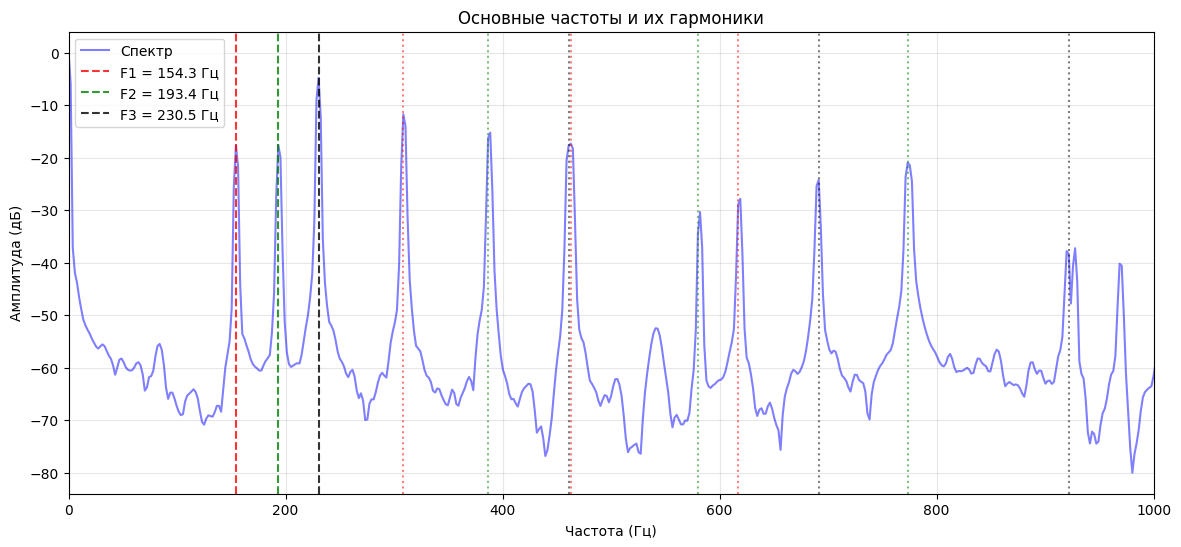

In [36]:
# Визуализация гармонических серий
plt.figure(figsize=(14, 6))
plt.plot(freq_subset, spec_subset, 'b-', alpha=0.5, label='Спектр')

colors = ['red', 'green', 'black']
for i, (freq, color) in enumerate(zip(main_freqs, colors)):
    # Отмечаем основную частоту
    plt.axvline(x=freq, color=color, linestyle='--', alpha=0.8, label=f'F{i+1} = {freq:.1f} Гц')
    
    # Отмечаем гармоники
    for n in [2, 3, 4]:
        harmonic_freq = freq * n
        plt.axvline(x=harmonic_freq, color=color, linestyle=':', alpha=0.5)

plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.title('Основные частоты и их гармоники')
plt.xlim([0, 1000])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Найденное трезвучие - трезвучие ре-диез-мажор